## Build TF-IDF matrix (Feature Extraction)

In [1]:
import pandas as pd
import ast

papers_tfidf = pd.read_csv('../data/papers_preprocessed.csv')
papers_tfidf['lemmatized_tokens'] = papers_tfidf['lemmatized_tokens'].apply(ast.literal_eval)
papers_tfidf['lemmatized_text'] = papers_tfidf['lemmatized_tokens'].apply(lambda x: ' '.join(x))

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000, 
    stop_words='english',
    ngram_range=(1, 1),
    max_df=0.85,  
    min_df=5      
)

tfidf_matrix = vectorizer.fit_transform(papers_tfidf['lemmatized_text'])
feature_names = vectorizer.get_feature_names_out()

## Extract top keywords (Baseline Model)

In [3]:
def get_tfidf_keywords(doc_index, top_n=5):
    row = tfidf_matrix[doc_index]
    
    word_indices = row.indices
    word_scores = row.data
    
    scores = [(feature_names[idx], score) for idx, score in zip(word_indices, word_scores)]
    
    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)
    return [word for word, score in sorted_scores[:top_n]]

papers_tfidf['tfidf_keywords'] = [get_tfidf_keywords(i) for i in range(len(papers_tfidf))]

In [4]:
for i in [0, 1, 2, 3, 4]:
    print(f"Paper {i}: {papers_tfidf['tfidf_keywords'][i]}")
    print()

Paper 0: ['state', 'synaptic', 'neuron', 'synaptic_weight', 'arithmetic']

Paper 1: ['environment', 'neuron', 'connectivity', 'entropy', 'bit']

Paper 2: ['neuron', 'hopfield', 'capacity', 'relation', 'convergence']

Paper 3: ['bump', 'neural_net', 'surface', 'neuron', 'input']

Paper 4: ['cell', 'node', 'queue', 'network', 'stimulation']



C:\Users\Reem\AppData\Local\Temp\ipykernel_17332\2839147203.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Keyword', data=top20, palette='Blues_d')


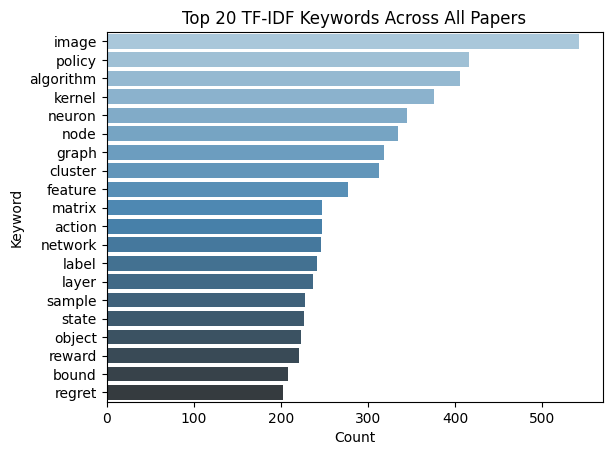

In [5]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

all_keywords = [kw for kws in papers_tfidf['tfidf_keywords'] for kw in kws]
top20 = pd.DataFrame(Counter(all_keywords).most_common(20), columns=['Keyword', 'Count'])
sns.barplot(x='Count', y='Keyword', data=top20, palette='Blues_d')
plt.title('Top 20 TF-IDF Keywords Across All Papers')
plt.show()

Save TF-IDF keywords

In [6]:
import json

with open('../results/tfidf_results.json', 'w') as f:
    json.dump(papers_tfidf['tfidf_keywords'].tolist(), f)

In [7]:
import joblib
import os

joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
joblib.dump(tfidf_matrix, '../models/tfidf_matrix.pkl')

['../models/tfidf_matrix.pkl']